# 6.6.2 遗忘、漂移与在线验证

## 学习目标与先修知识

能推导遗忘因子（forgetting factor）改变历史数据及初始正则项的方式，比较参数（parameter）漂移、噪声与弱激励；能按先预测后更新的时钟选择遗忘因子，在独立留出时段报告在线误差而不泄漏未来信息。

先修：[从批量最小二乘到递推更新](01-从批量最小二乘到递推更新.ipynb)、[数据划分与独立验证](../05-动态辨识、实验设计与验证/03-数据划分与独立验证.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

培养条件缓慢改变时，早期参数不再代表当前交换与清除。保留全部历史会使反应迟缓；把历史忘得太快又可能让估计追随噪声。我们需要同时说明记忆规则、当前读数何时进入计算，以及用哪段数据决定记忆长短。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'


## 初步实验

In [2]:
forgetting = .8
count = 5
weights = forgetting ** np.arange(count-1, -1, -1)
display(Markdown(show_table(['到达顺序', '当前残差权重'], list(enumerate(weights, start=1)))))
print('初始正则项当前权重：', forgetting**count)

| 到达顺序 | 当前残差权重 |
| --- | --- |
| 1 | 0.4096 |
| 2 | 0.512 |
| 3 | 0.64 |
| 4 | 0.8 |
| 5 | 1 |

初始正则项当前权重： 0.3276800000000001


## 模型假设

沿用无量纲（dimensionless）清除回归 $y_n=\phi_n^\mathsf{T}\theta_n+\epsilon_n$。回归量在目标到达前已知，误差独立且均值为零；初始矩阵（matrix）正定（positive definite）。比较固定系数与缓慢改变的系数，但估计器并不知道生成参数。指数遗忘是跟踪规则，不是宣称真实参数恰好服从某个随机过程（stochastic process）。

本节时钟固定：0—79先运行积累，80—139是调参区间，140—199是最终评估。候选 λ 为0.9、0.97、1，查看数据前固定。评估区间**仍每拍先预测、后得到读数并更新**，因此它衡量已锁定协议的在线性能，不是参数冻结后整段无反馈（feedback）外推。

## 数学解释与推导

### 将旧目标整体乘一个因子

设 $0<\lambda\le1$，定义 $J_n=\lambda J_{n-1}+(y_n-\phi_n^\mathsf{T}\theta)^2$，展开得到
$$J_n(\theta)=\lambda^n(\theta-\theta_0)^\mathsf{T}H_0(\theta-\theta_0)
+\sum_{i=1}^{n}\lambda^{n-i}(y_i-\phi_i^\mathsf{T}\theta)^2.$$
最新一条权重是1；初始项经过 n 次遗忘，权重是 $\lambda^n$。若初始惩罚不衰减，那是另一个目标，不能拿它核对下面的递推。λ=1 退回上一节；λ=0 会除零且丢掉所需信息，不在模型（model）范围内。

因此 $H_n=\lambda H_{n-1}+\phi_n\phi_n^\mathsf{T}$、$b_n=\lambda b_{n-1}+\phi_n y_n$。对 $\lambda H_{n-1}$ 用上一节的秩（rank）一公式，其逆为 $P_{n-1}/\lambda$，整理为
$$K_n=\frac{P_{n-1}\phi_n}{\lambda+\phi_n^\mathsf{T}P_{n-1}\phi_n},\qquad
P_n=\frac{P_{n-1}-K_n\phi_n^\mathsf{T}P_{n-1}}{\lambda},$$
$$\theta_n=\theta_{n-1}+K_n(y_n-\phi_n^\mathsf{T}\theta_{n-1}).$$
旧记录年龄增加 m 时，权重变成 $\lambda^m$。几何级数和 $1/(1-\lambda)$ 在无限记录下描述总权重规模，**不是所有设计下严格等价的独立样本数**。固定设计（fixed design）和同方差（homoscedasticity）噪声下，加权估计的抽样协方差（covariance）为 $\sigma^2H_n^{-1}\Phi^\mathsf{T}W^2\Phi H_n^{-1}$；初始中心仍固定，不能直接写成 $\sigma^2P_n$。

### 没被激励的方向会怎样

若每行都为 $(1,0)$ 且 P₀ 无交叉项，第二个参数始终未被观测（observation）直接约束，而 $P_{22,n}=P_{22,0}/\lambda^n$。遗忘会削弱旧约束，却无法制造第二个方向的信息。持续激励（persistent excitation）要求一段段回归量的外积和在所有参数方向都有足够正的下界；短数据中满秩只是一项有限记录检查，不自动证明持续激励。更快追随某条输出（output）也不等于所有参数一致收敛。

### 先锁定协议，再打开评估时段

对每个候选从同一初始化运行到调参段结束，只在调参索引上比较更新前预测的均方误差。按 (误差, λ) 升序决定，完全并列取较小 λ。锁定后重跑同一个历史前缀并继续评估；重跑只为实现清晰，不改变已锁定的选择。每拍先预测并评分，读数到达后再更新估计，用于**后续**预测；评估阶段保持已选 λ 不变。

## 核心实现

In [3]:
def rls_trace(regressors, observed, initial_parameters, initial_inverse, forgetting):
    parameters = initial_parameters.copy()
    inverse = [row.copy() for row in initial_inverse]
    dimension = len(parameters)
    predictions, parameter_history, inverse_history = [], [], []
    for features, target in zip(regressors, observed):
        prediction = sum(x * b for x, b in zip(features, parameters))
        direction = [sum(inverse[i][j] * features[j] for j in range(dimension))
                     for i in range(dimension)]
        denominator = forgetting + sum(x * v for x, v in zip(features, direction))
        gain = [v / denominator for v in direction]
        error = target - prediction
        parameters = [b + g * error for b, g in zip(parameters, gain)]
        inverse = [[(inverse[i][j] - direction[i] * direction[j] / denominator) / forgetting
                    for j in range(dimension)] for i in range(dimension)]
        predictions.append(prediction)
        parameter_history.append(parameters.copy())
        inverse_history.append([row.copy() for row in inverse])
    return predictions, parameter_history, inverse_history

def select_forgetting(regressors, observed, candidates, initial_parameters,
                      initial_inverse, tuning_start, evaluation_start):
    tuning_scores = []
    for forgetting in sorted(set(candidates)):
        predictions, _, _ = rls_trace(
            regressors[:evaluation_start], observed[:evaluation_start],
            initial_parameters, initial_inverse, forgetting)
        errors = [(predictions[i] - observed[i]) ** 2
                  for i in range(tuning_start, evaluation_start)]
        tuning_scores.append((sum(errors) / len(errors), forgetting))
    chosen = min(tuning_scores)[1]
    predictions, parameter_history, _ = rls_trace(
        regressors, observed, initial_parameters, initial_inverse, chosen)
    test_errors = [(predictions[i] - observed[i]) ** 2
                   for i in range(evaluation_start, len(observed))]
    score = (sum(test_errors) / len(test_errors)) ** 0.5
    return chosen, parameter_history[-1], score


In [4]:
def weighted_batch_trace(regressors, observed, initial_parameters, initial_inverse, forgetting):
    # 每个前缀重新构造整个目标函数，不复用递推增益公式。
    features = np.asarray(regressors, dtype=float)
    targets = np.asarray(observed, dtype=float)
    initial = np.asarray(initial_parameters, dtype=float)
    initial_information = np.linalg.inv(np.asarray(initial_inverse, dtype=float))
    parameters, inverses, predictions = [], [], []
    previous = initial.copy()
    for count in range(1, len(targets) + 1):
        predictions.append(float(features[count - 1] @ previous))
        weights = forgetting ** np.arange(count - 1, -1, -1)
        design = features[:count]
        information = forgetting ** count * initial_information + design.T @ (weights[:, None] * design)
        right = forgetting ** count * initial_information @ initial + design.T @ (weights * targets[:count])
        previous = np.linalg.solve(information, right)
        parameters.append(previous.copy())
        inverses.append(np.linalg.solve(information, np.eye(len(initial))))
    return predictions, parameters, inverses


## 对照实验

用同一组回归量与同一串标准化噪声分别构造固定参数、缓慢漂移、固定参数但噪声扩大三组；NumPy default_rng种子6621，200条。另设弱激励对照。真实系数仅用于绘图核对；调参函数只接收回归量与目标读数。


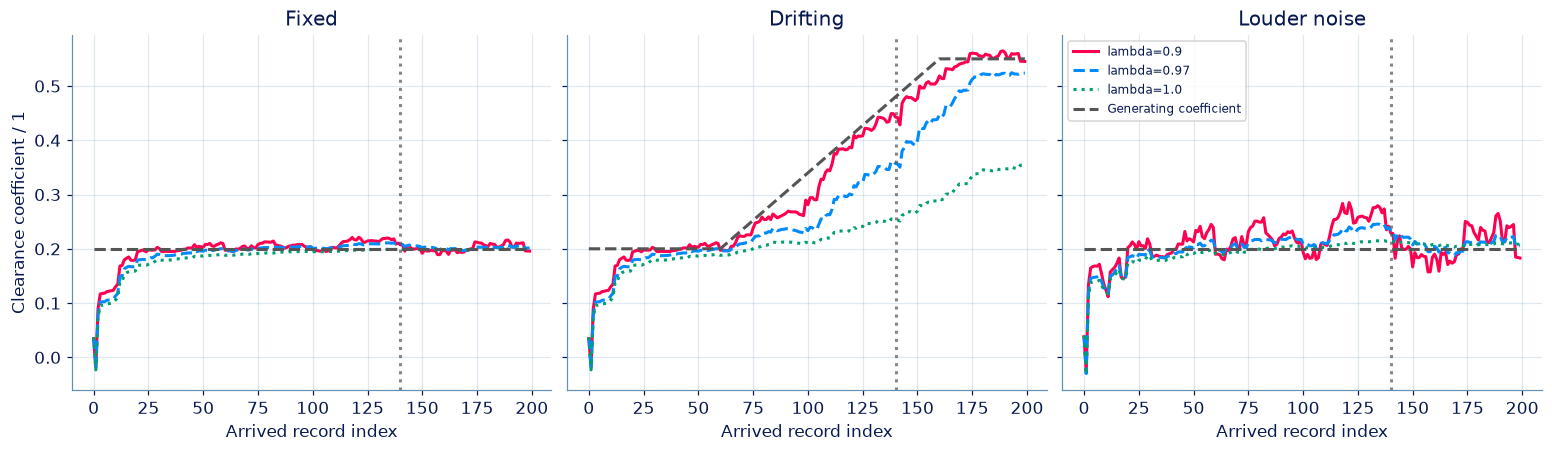

| 课程对照 | 仅由调参段选定的λ | 最终在线RMSE / 1 |
| --- | --- | --- |
| Fixed | 0.97 | 0.0276761 |
| Drifting | 0.9 | 0.0395849 |
| Louder noise | 0.97 | 0.11076 |

In [5]:
rng = np.random.default_rng(6621)
steps = np.arange(200)
regressors = np.column_stack([rng.uniform(.2, 1.8, 200), -rng.uniform(.1, 2., 200)])
base_noise = rng.normal(0., 1., 200)
constant_truth = np.tile([.7, .2], (200, 1))
drifting_truth = constant_truth.copy()
drifting_truth[:, 1] += .35 * np.clip((steps - 60) / 100, 0., 1.)
records = {
    'Fixed': (np.sum(regressors * constant_truth, axis=1) + .025 * base_noise, constant_truth),
    'Drifting': (np.sum(regressors * drifting_truth, axis=1) + .025 * base_noise, drifting_truth),
    'Louder noise': (np.sum(regressors * constant_truth, axis=1) + .1 * base_noise, constant_truth),
}
initial_parameters = [.1, .1]; initial_inverse = [[2., 0.], [0., 2.]]
candidates = [.9, .97, 1.]; tuning_start, evaluation_start = 80, 140
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
rows = []
for ax, (label, (observed, truth)) in zip(axes, records.items()):
    chosen, final, score = select_forgetting(regressors.tolist(), observed.tolist(), candidates,
                                            initial_parameters, initial_inverse, tuning_start, evaluation_start)
    for value, color in zip(candidates, [PINK, BLUE, GREEN]):
        predictions, history, _ = rls_trace(regressors.tolist(), observed.tolist(), initial_parameters, initial_inverse, value)
        ax.plot(steps, np.array(history)[:, 1], color=color, ls={.9: '-', .97: '--', 1.: ':'}[value], label=f'lambda={value}')
    ax.plot(steps, truth[:, 1], color=GRAY, ls='--', label='Generating coefficient')
    ax.axvline(evaluation_start, color=GRAY, ls=':', alpha=.7)
    ax.set(xlabel='Arrived record index', title=label)
    rows.append((label, chosen, score))
axes[0].set_ylabel('Clearance coefficient / 1')
axes[2].legend(fontsize=8)
plt.show()
display(Markdown(show_table(['课程对照', '仅由调参段选定的λ', '最终在线RMSE / 1'], rows)))

把弱激励作为独立问题检查。以下比较只改变第二个回归方向是否出现；第二个图画 P 的第二对角元，不能把它不加条件解释为估计方差（variance）。

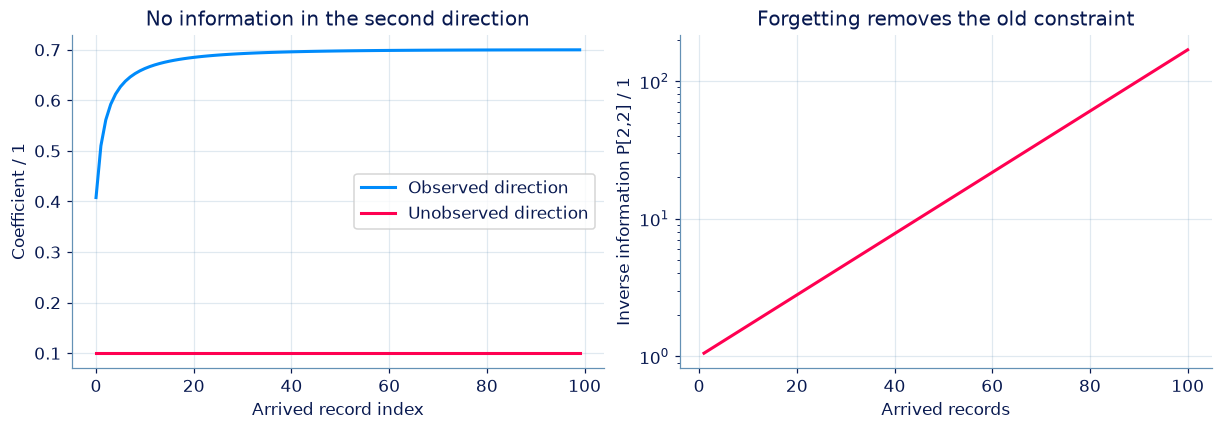

In [6]:
weak = np.column_stack([np.ones(100), np.zeros(100)])
weak_target = np.full(100, .7)
weak_predictions, weak_parameters, weak_inverse = rls_trace(weak.tolist(), weak_target.tolist(), [.1, .1], [[1., 0.], [0., 1.]], .95)
weak_parameters, weak_inverse = np.array(weak_parameters), np.array(weak_inverse)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(weak_parameters[:, 0], color=BLUE, label='Observed direction')
axes[0].plot(weak_parameters[:, 1], color=PINK, label='Unobserved direction')
axes[0].set(xlabel='Arrived record index', ylabel='Coefficient / 1', title='No information in the second direction')
axes[0].legend()
axes[1].semilogy(np.arange(1, 101), weak_inverse[:, 1, 1], color=PINK)
axes[1].set(xlabel='Arrived records', ylabel='Inverse information P[2,2] / 1', title='Forgetting removes the old constraint')
plt.show()
np.testing.assert_allclose(weak_parameters[:, 1], .1)
np.testing.assert_allclose(weak_inverse[:, 1, 1], .95 ** -np.arange(1, 101))

### 批量独立核对与隔离检查

逐前缀重建加权目标，初始项明确乘 λⁿ；然后把最终评估的目标改成极端值，确认候选选择仍完全相同。预测隔离另将当前及未来目标一起改写，检查当前预测不变。

In [7]:
observed = records['Drifting'][0]
max_errors = []
for value in candidates:
    direct = rls_trace(regressors.tolist(), observed.tolist(), initial_parameters, initial_inverse, value)
    batch = weighted_batch_trace(regressors, observed, initial_parameters, initial_inverse, value)
    for recursive_array, batch_array in zip(direct, batch):
        np.testing.assert_allclose(recursive_array, batch_array, atol=1e-10, rtol=1e-10)
    max_errors.append(float(np.max(np.abs(np.array(direct[1])-batch[1]))))
chosen = select_forgetting(regressors.tolist(), observed.tolist(), candidates, initial_parameters, initial_inverse, 80, 140)[0]
changed = observed.copy(); changed[140:] = np.linspace(-20, 20, 60)
assert chosen == select_forgetting(regressors.tolist(), changed.tolist(), candidates, initial_parameters, initial_inverse, 80, 140)[0]
original_predictions = rls_trace(regressors.tolist(), observed.tolist(), initial_parameters, initial_inverse, chosen)[0]
changed_predictions = rls_trace(regressors.tolist(), changed.tolist(), initial_parameters, initial_inverse, chosen)[0]
np.testing.assert_allclose(original_predictions[:141], changed_predictions[:141])
print('各候选逐前缀最大差：', max_errors)
print('最终目标不改变λ选择；当前目标不改变当前评分预测。')

各候选逐前缀最大差： [1.7208456881689926e-15, 2.4980018054066022e-15, 2.3314683517128287e-15]
最终目标不改变λ选择；当前目标不改变当前评分预测。


## 结果解释

同一噪声实现下，短记忆对漂移响应较快；固定参数对照却能看到更明显的估计波动。噪声扩大对照提醒我们：误差变大不只可能来自参数变化。选择 λ 时，需要同时权衡漂移响应和估计波动。

弱激励时第二参数保持初始值，P 的对应对角元却持续变大。要改善该方向的辨识，应增加能区分参数的观测条件，或者重新限定模型目标；缩短记忆不能替代信息。

最终在线成绩只评价当前固定候选集、调参协议和信息时钟。评估目标可在到达后帮助后续预测，却没有参与方案选择；若目标是整段无反馈预测，必须另做冻结参数或自由运行（free-run simulation）实验。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：初始约束也会被遗忘

每次更新使用 Hₙ=λHₙ₋₁+φₙφₙᵀ、bₙ=λbₙ₋₁+φₙyₙ，0<λ<1。第 n 条之后，哪一个目标与此递推对应？

- **A.** 初始正则项权重固定为1，每条历史残差（residual）的权重也固定为1。
- **B.** 初始正则项乘 λⁿ，第 i 条残差平方乘 λⁿ⁻ⁱ。
- **C.** 只有最新目标乘 λ，所有旧数据权重不变。
- **D.** 只对参数（parameter）值乘 λ，而信息矩阵（matrix）不变。

[作答：初始约束也会被遗忘](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-forgetting-objective)

### 第 2 题 · Python 计算题：写出当前批量目标的权重

当前已收到 count 条记录。按指数遗忘规则，返回初始正则项的权重以及从最旧到最新的残差（residual）权重，用来重新构造与递推等价的批量问题。

**函数与代码模板**

```python
def solve(
    count: int,
    forgetting: float,
) -> tuple[float, list[float]]:
    # 按题定顺序返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `count` | `int` | 已到达的记录数 n。 | 条 |
| `forgetting` | `float` | 遗忘因子（forgetting factor） λ。 | 无量纲 |

**返回值**

按以下顺序返回元组：(initial_weight, observation_weights)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial_weight` | `float` | 初始正则项权重 λⁿ。 | 无量纲 |
| `observation_weights` | `list[float]` | 依到达顺序排列的 λⁿ⁻¹,…,λ⁰。 | 无量纲 |

**计算规则**

返回 (forgetting\*\*count, [forgetting\*\*(count-1-i) for i in range(count)])。count=0 时返回 (1, [])；不要倒置新旧数据的权重。

**约束与边界**

- 0≤count≤100；0.5≤forgetting≤1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| count | 已到达的记录数 n。 | 3 | 条 |
| forgetting | 遗忘因子（forgetting factor） λ。 | 0.5 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
count = 3
forgetting = 0.5

result = solve(count, forgetting)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| initial_weight | 初始正则项权重 λⁿ。 | 0.125 | 无量纲 |
| observation_weights | 依到达顺序排列的 λⁿ⁻¹,…,λ⁰。 | [0.25, 0.5, 1.0] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.125, [0.25, 0.5, 1.0])
```

**样例解释**

三条之后初始权重为1/8；第一、二、三条读数权重分别为1/4、1/2、1。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：写出当前批量目标的权重](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-forgetting-weights)

### 第 3 题 · 多项选择题：在线误差应在哪一步计算

目标读数 yₙ 即将到达，当前只有参数（parameter） θₙ₋₁ 和已知回归量 φₙ。以下哪些操作符合先预测后更新的在线评估？

- **A.** 先固定 ŷₙ=φₙᵀθₙ₋₁，再读取 yₙ、记误差并更新。
- **B.** 先用 yₙ 更新参数，再用 φₙᵀθₙ 作为当时的预测成绩。
- **C.** 在留出时段允许按预先固定的规则继续更新，但不能用该时段选遗忘因子（forgetting factor）。
- **D.** 若应用场景不再获得目标读数，应另评估冻结参数或自由运行（free-run simulation），不能沿用在线更新成绩。

[作答：在线误差应在哪一步计算](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-online-clock)

### 第 4 题 · 多项选择题：弱激励不能靠遗忘制造信息

两个参数（parameter）的回归向量（vector）长期都是 [1,0]，λ=0.95，P₀ 是单位矩阵（identity matrix）。以下哪些判断成立？

- **A.** 第二参数方向没有数据激励，第二分量不会自动靠真实数据收敛。
- **B.** 第二方向的 P 分量按 1/λ 增长，提示旧约束逐渐消失。
- **C.** 把 λ 再减小一定能恢复第二参数的真实值。
- **D.** 第一分量跟踪较好，不能作为两个分量都被辨识的证据。

[作答：弱激励不能靠遗忘制造信息](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-forgetting-excitation)

### 第 5 题 · 多项选择题：跟得快和估得准不是同一件事

对同一设计分别比较固定系数、系数漂移及噪声增大三组课程实验，并只在调参时段选择 λ。哪些解释合理？

- **A.** 较小 λ 常能更快响应漂移，但也可能放大固定参数（parameter）下的波动。
- **B.** 一次漂移轨迹（trajectory）误差下降证明参数估计在任意噪声下都一致。
- **C.** 漂移和噪声增大都可能改变误差，要结合激励和预先固定的对照判断。
- **D.** 若最终评估不佳，应如实报告；按评估结果重选 λ 后须另留未见时段。

[作答：跟得快和估得准不是同一件事](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-drift-noise-validation)

参考：[MIT 6.435 第9、21讲](https://ocw.mit.edu/courses/6-435-system-identification-spring-2005/pages/lecture-notes/)讨论最小二乘性质与递推估计；[MIT 2.161 的 RLS 讲义](https://ocw.mit.edu/courses/2-161-signal-processing-continuous-and-discrete-fall-2008/0908e93cb4f31eac9150b14c1ffdf328_rls.pdf)第2节提供指数遗忘与矩阵更新的补充推导。本节给出适合本课程的独立推导与检算。